In [6]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"C:\Users\FARJAD FARHAT\Downloads\MLProject\Phase1\scaledDelay.csv")
df

,Flight Number,Type,Status,Departure IATA Code,Departure ICAO Code,Scheduled Time,Actual Time,Arrival IATA Code,Arrival ICAO Code,Arrival Estimated Time,...,Humidity (%)Max,Humidity (%)avg,Humidity (%)Min,Wind Speed (mph)Max,Wind Speed (mph)avg,Wind Speed (mph)Min,Pressure (in)Max,Pressure (in)avg,Pressure (in)Min,departure_delay
0,737,departure,active,lhe,opla,2023-07-20 20:50:00,2023-07-20 20:15:00,ruh,oerk,2023-07-20 21:54:00,...,0.531856,0.827797,1.089088,-0.329007,-0.095441,-0.345092,-0.897460,-0.454550,0.269328,0.000000
1,843,departure,active,lhe,opla,2023-07-18 15:05:00,NaN,khi,opkc,NaN,...,0.180001,0.691515,1.089088,0.068143,1.164024,-0.345092,-1.337505,-0.454550,0.269328,0.000000
2,841,departure,active,lhe,opla,2023-07-23 09:50:00,NaN,khi,opkc,NaN,...,0.109630,0.530455,0.709605,-0.170147,0.624254,-0.345092,-0.457415,-0.180812,0.281751,0.000000
3,205,departure,active,lhe,opla,2023-07-26 23:30:00,2023-07-26 23:51:00,kwi,okkk,2023-07-27 01:24:00,...,1.305935,0.914521,0.872240,0.068143,0.624254,-0.345092,-0.897460,-0.180812,0.281751,0.855338
4,723,departure,active,lhe,opla,2023-07-20 11:35:00,NaN,dxb,omdb,NaN,...,0.531856,0.827797,1.089088,-0.329007,-0.095441,-0.345092,-0.897460,-0.454550,0.269328,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51567,841,departure,active,lhe,opla,2023-11-16 09:50:00,2023-11-16 10:03:00,khi,opkc,2023-11-16 11:34:00,...,0.039260,0.177362,-0.049361,-0.726157,-1.252092,-0.345092,1.302765,0.914143,0.343869,0.000000
51568,735,departure,active,lhe,opla,2023-11-16 11:40:00,2023-11-16 11:48:00,jed,oejn,2023-11-16 14:48:00,...,0.039260,0.177362,-0.049361,-0.726157,-1.252092,-0.345092,1.302765,0.914143,0.343869,0.000000
51569,203,departure,active,lhe,opla,2023-11-27 10:50:00,NaN,dxb,omdb,NaN,...,0.461485,0.728683,0.926452,-0.329007,-0.866542,-0.345092,0.862720,0.914143,0.331445,0.000000
51570,898,departure,active,lhe,opla,2023-11-19 02:00:00,NaN,kul,wmkk,NaN,...,0.461485,0.226919,-0.049361,-0.646727,-1.072169,-0.345092,1.302765,-0.728289,-3.296211,0.000000


In [8]:
df['Scheduled Time'] = pd.to_datetime(df['Scheduled Time'], errors='coerce')
df['Actual Time'] = pd.to_datetime(df['Actual Time'], errors='coerce')

Text(0, 0.5, 'Frequency')

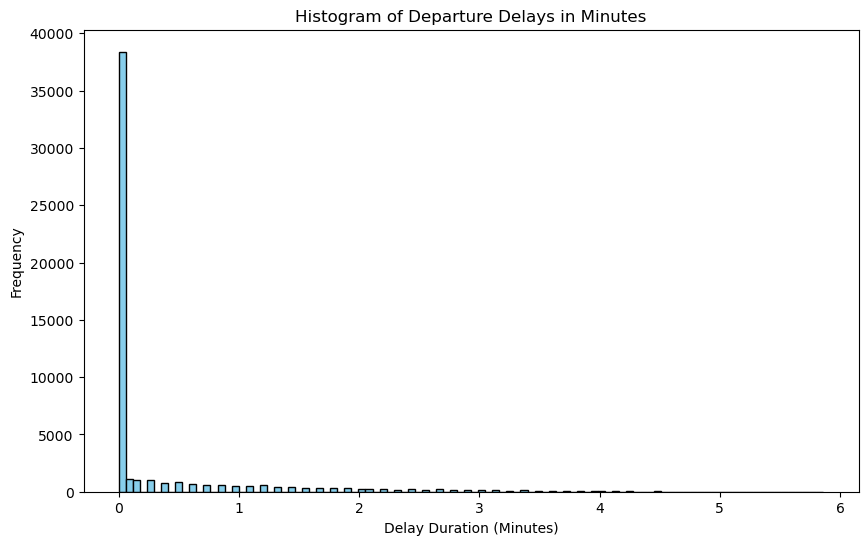

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df['departure_delay'].dropna(), bins=100, edgecolor='black', color='skyblue')
plt.title('Histogram of Departure Delays in Minutes')
plt.xlabel('Delay Duration (Minutes)')
plt.ylabel('Frequency')

D:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


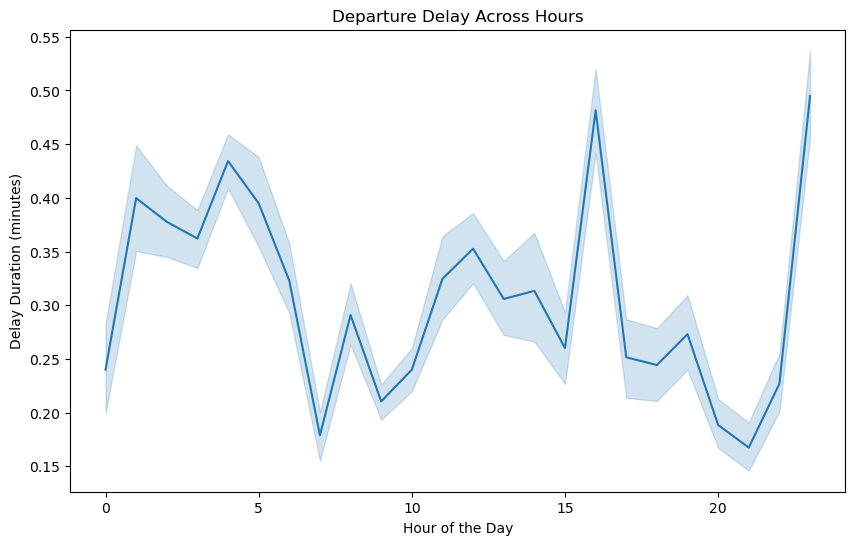

In [10]:
df['hour'] = df['Scheduled Time'].dt.hour

plt.figure(figsize=(10, 6))
sns.lineplot(x=df['hour'], y=df['departure_delay'])
plt.title('Departure Delay Across Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Delay Duration (minutes)')
plt.show()


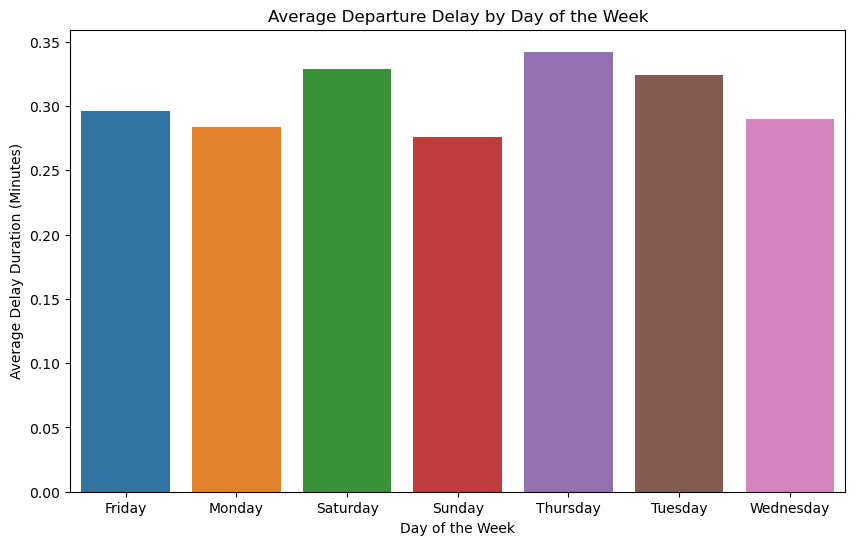

In [11]:
df['day_of_week'] = df['Scheduled Time'].dt.day_name()
day_delay = df.groupby('day_of_week')['departure_delay'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='day_of_week', y='departure_delay', data=day_delay)
plt.title('Average Departure Delay by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Delay Duration (Minutes)')
plt.show()


D:\Anaconda\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


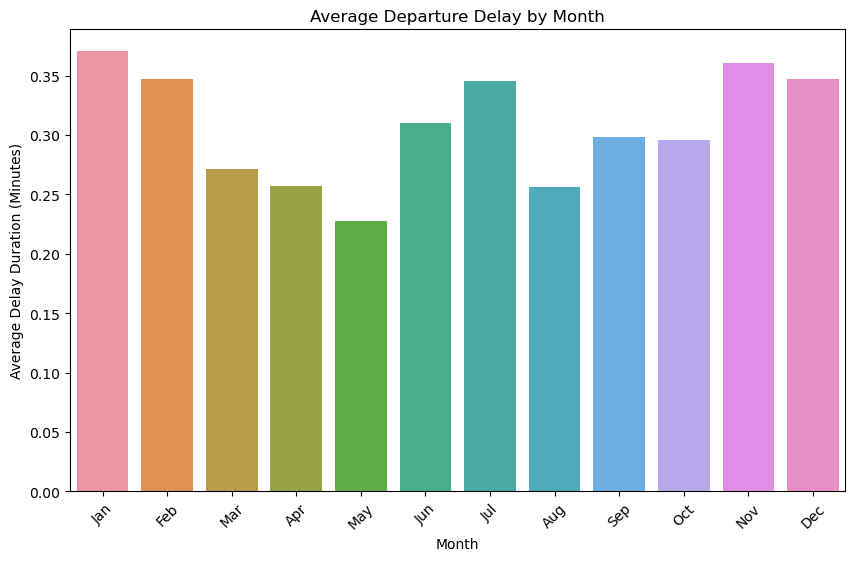

In [12]:

month_delay = df.groupby('Month')['departure_delay'].mean().reset_index()
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_delay['Month'] = pd.Categorical(month_delay['Month'], categories=month_order, ordered=True)
month_delay = month_delay.sort_values('Month')

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='departure_delay', data=month_delay)
plt.title('Average Departure Delay by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay Duration (Minutes)')
plt.xticks(rotation=45)
plt.show()


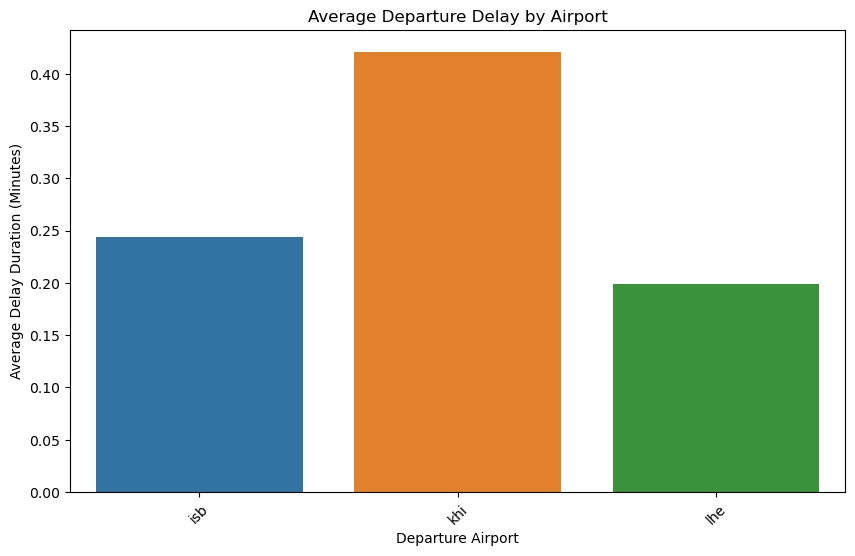

In [14]:
airport_delay = df.groupby('Departure IATA Code')['departure_delay'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Departure IATA Code', y='departure_delay', data=airport_delay)
plt.title('Average Departure Delay by Airport')
plt.xlabel('Departure Airport')
plt.ylabel('Average Delay Duration (Minutes)')
plt.xticks(rotation=45)
plt.show()


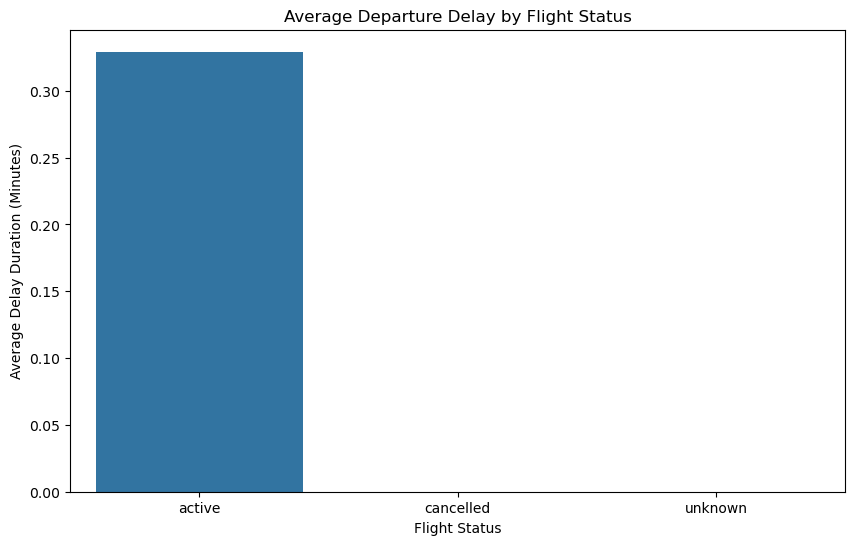

In [16]:
status_delay = df.groupby('Status')['departure_delay'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Status', y='departure_delay', data=status_delay)
plt.title('Average Departure Delay by Flight Status')
plt.xlabel('Flight Status')
plt.ylabel('Average Delay Duration (Minutes)')
plt.show()


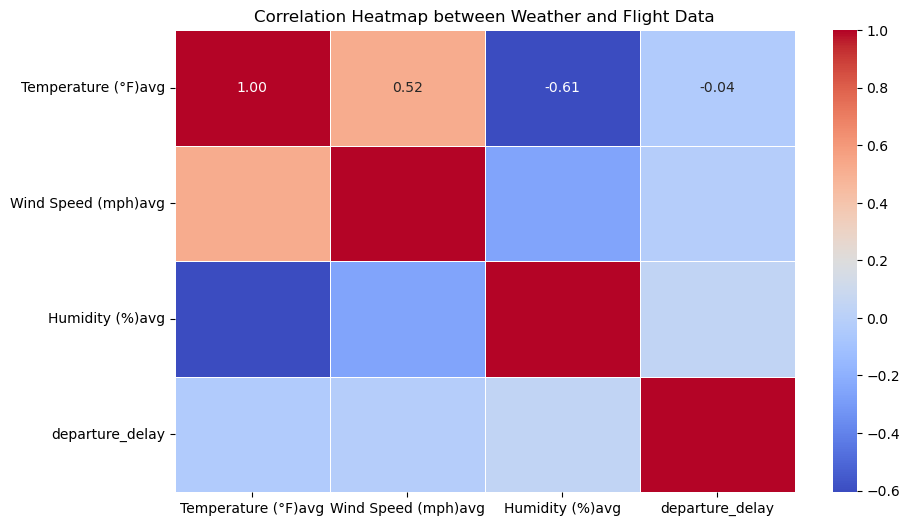

In [17]:
corr_matrix = df[['Temperature (°F)avg', 'Wind Speed (mph)avg', 'Humidity (%)avg','departure_delay']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap between Weather and Flight Data')
plt.show()

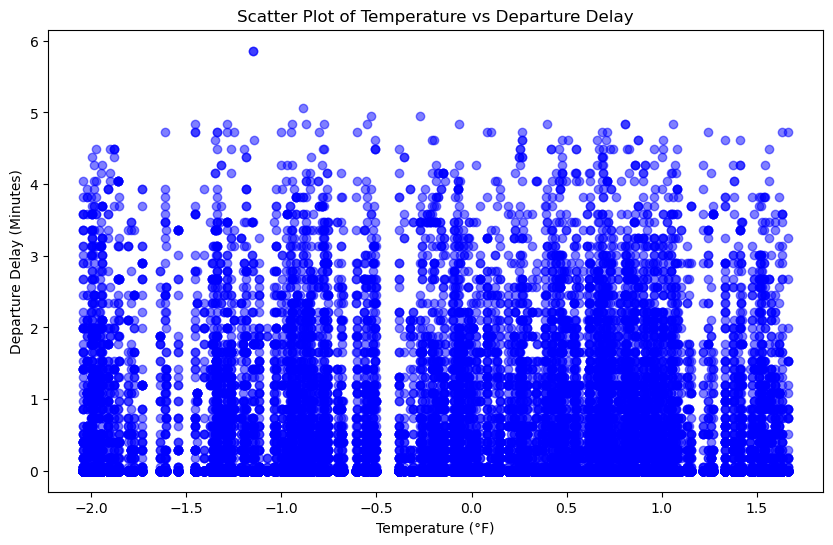

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Temperature (°F)avg'], df['departure_delay'], color='blue', alpha=0.5)
plt.title('Scatter Plot of Temperature vs Departure Delay')
plt.xlabel('Temperature (°F)')
plt.ylabel('Departure Delay (Minutes)')
plt.show()


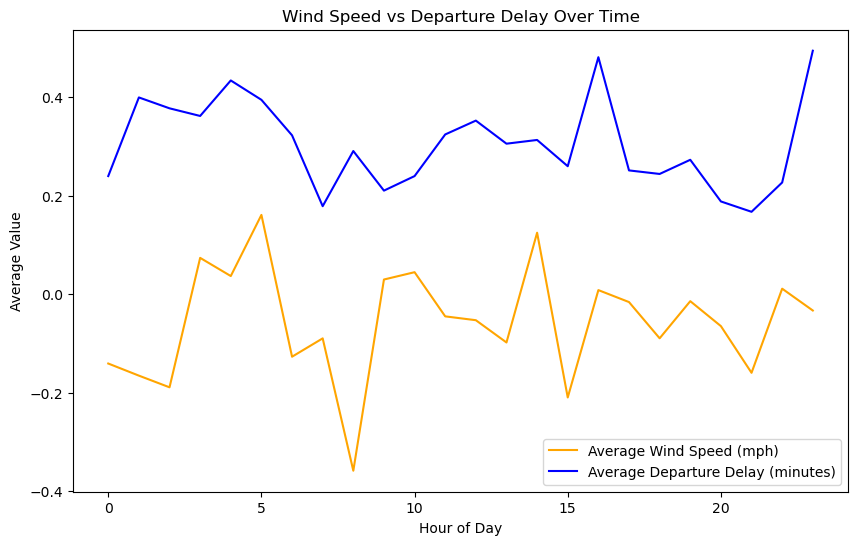

In [19]:
df['Hour'] = df['Scheduled Time'].dt.hour
avg_wind_delay = df.groupby('Hour')[['Wind Speed (mph)avg', 'departure_delay']].mean()
plt.figure(figsize=(10, 6))
plt.plot(avg_wind_delay.index, avg_wind_delay['Wind Speed (mph)avg'], label='Average Wind Speed (mph)', color='orange')
plt.plot(avg_wind_delay.index, avg_wind_delay['departure_delay'], label='Average Departure Delay (minutes)', color='blue')
plt.title('Wind Speed vs Departure Delay Over Time')
plt.xlabel('Hour of Day')
plt.ylabel('Average Value')
plt.legend()
plt.show()
